# 04_results_visualization_ideal

This notebook reads the exported benchmark solution files and turns them into report-ready tables and figures.

Main tasks:
1. validate the benchmark solution exports
2. summarize the plan before and after optimization
3. visualize the cost mix and intervention structure
4. export tables and charts used in the report


## Setup and benchmark outputs

The notebook starts by loading the benchmark parameter and solution files produced by Notebooks 02 and 03.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

IDEAL_DIR = PROJECT_ROOT / "data" / "processed" / "ideal"
SOLUTIONS_DIR = PROJECT_ROOT / "results" / "solutions"

EXPORT_TABLE_DIR = PROJECT_ROOT / "data" / "exports" / "tables_for_report"
EXPORT_FIG_DIR = PROJECT_ROOT / "data" / "exports" / "figures"

EXPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IDEAL_DIR:", IDEAL_DIR)
print("SOLUTIONS_DIR:", SOLUTIONS_DIR)
print("EXPORT_TABLE_DIR:", EXPORT_TABLE_DIR)
print("EXPORT_FIG_DIR:", EXPORT_FIG_DIR)

PROJECT_ROOT: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project
IDEAL_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/processed/ideal
SOLUTIONS_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/results/solutions
EXPORT_TABLE_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/tables_for_report
EXPORT_FIG_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures


In [4]:
required_files = [
    IDEAL_DIR / "zipcode_demand_supply_ideal.csv",
    SOLUTIONS_DIR / "zipcode_solution_ideal.csv",
    SOLUTIONS_DIR / "facility_solution_ideal.csv",
    SOLUTIONS_DIR / "new_build_solution_ideal.csv",
    SOLUTIONS_DIR / "objective_breakdown_ideal.csv",
    SOLUTIONS_DIR / "summary_stats_ideal.csv",
    SOLUTIONS_DIR / "run_metadata_ideal.csv"
]

for p in required_files:
    print(p.name, "exists ->", p.exists())

zipcode_demand_supply_ideal.csv exists -> True
zipcode_solution_ideal.csv exists -> True
facility_solution_ideal.csv exists -> True
new_build_solution_ideal.csv exists -> True
objective_breakdown_ideal.csv exists -> True
summary_stats_ideal.csv exists -> True
run_metadata_ideal.csv exists -> True


In [5]:
zip_input = pd.read_csv(IDEAL_DIR / "zipcode_demand_supply_ideal.csv")

zipcode_solution = pd.read_csv(SOLUTIONS_DIR / "zipcode_solution_ideal.csv")
facility_solution = pd.read_csv(SOLUTIONS_DIR / "facility_solution_ideal.csv")
new_build_solution = pd.read_csv(SOLUTIONS_DIR / "new_build_solution_ideal.csv")
objective_breakdown = pd.read_csv(SOLUTIONS_DIR / "objective_breakdown_ideal.csv")
summary_stats = pd.read_csv(SOLUTIONS_DIR / "summary_stats_ideal.csv")
run_metadata = pd.read_csv(SOLUTIONS_DIR / "run_metadata_ideal.csv")

## Summary tables and validation checks

These cells confirm that the benchmark outputs are internally consistent before building the report tables and visual summaries.


In [6]:
#Basic validation checks
validation_summary = pd.DataFrame([
    {
        "check": "all_zipcodes_meet_total_requirement_after",
        "value": int((zipcode_solution["meets_total_requirement_after"] == 1).all())
    },
    {
        "check": "all_zipcodes_meet_under5_requirement_after",
        "value": int((zipcode_solution["meets_under5_requirement_after"] == 1).all())
    },
    {
        "check": "all_zipcodes_meet_all_requirements_after",
        "value": int((zipcode_solution["all_requirements_met_after"] == 1).all())
    },
    {
        "check": "no_negative_total_surplus_after",
        "value": int((zipcode_solution["total_capacity_surplus_after"] >= -1e-6).all())
    },
    {
        "check": "no_negative_under5_surplus_after",
        "value": int((zipcode_solution["under5_capacity_surplus_after"] >= -1e-6).all())
    }
])

display(validation_summary)

,check,value
0,all_zipcodes_meet_total_requirement_after,1
1,all_zipcodes_meet_under5_requirement_after,1
2,all_zipcodes_meet_all_requirements_after,1
3,no_negative_total_surplus_after,1
4,no_negative_under5_surplus_after,1


In [7]:
#Baseline before/after summary table
before_after_summary = pd.DataFrame([
    {
        "metric": "zipcodes_desert_before_total_rule",
        "before": int(zipcode_solution["is_desert_total_before"].sum()),
        "after": int((zipcode_solution["meets_total_requirement_after"] == 0).sum())
    },
    {
        "metric": "zipcodes_under5_short_before",
        "before": int(zipcode_solution["is_under5_short_before"].sum()),
        "after": int((zipcode_solution["meets_under5_requirement_after"] == 0).sum())
    },
    {
        "metric": "zipcodes_needing_intervention_before",
        "before": int(zipcode_solution["needs_intervention_before"].sum()),
        "after": int((zipcode_solution["all_requirements_met_after"] == 0).sum())
    },
    {
        "metric": "citywide_total_gap",
        "before": float(zipcode_solution["gap_total"].sum()),
        "after": float(np.maximum(0, zipcode_solution["req_total"] - zipcode_solution["final_total_capacity"]).sum())
    },
    {
        "metric": "citywide_under5_gap",
        "before": float(zipcode_solution["gap_under5"].sum()),
        "after": float(np.maximum(0, zipcode_solution["req_under5"] - zipcode_solution["final_under5_capacity"]).sum())
    }
])

display(before_after_summary)

,metric,before,after
0,zipcodes_desert_before_total_rule,162.0,0.0
1,zipcodes_under5_short_before,179.0,0.0
2,zipcodes_needing_intervention_before,180.0,0.0
3,citywide_total_gap,236460.0,0.0
4,citywide_under5_gap,277721.0,0.0


In [8]:
#Overall plan summary table
total_added_expansion = facility_solution["x_added"].sum()
total_added_under5_expansion = facility_solution["u_under5_added"].sum()

if len(new_build_solution) > 0:
    total_new_facilities = new_build_solution["num_new_facilities"].sum()
    total_added_newbuild = (
        new_build_solution["num_new_facilities"] *
        new_build_solution["new_total_capacity_per_facility"]
    ).sum()
    total_added_under5_newbuild = new_build_solution["new_under5_assigned"].sum()
else:
    total_new_facilities = 0
    total_added_newbuild = 0
    total_added_under5_newbuild = 0

objective_value = float(
    objective_breakdown.loc[
        objective_breakdown["component"] == "total_objective", "value"
    ].iloc[0]
)

overall_plan_summary = pd.DataFrame([
    {"metric": "minimum_total_funding", "value": objective_value},
    {"metric": "total_added_expansion_slots", "value": total_added_expansion},
    {"metric": "total_added_under5_expansion_slots", "value": total_added_under5_expansion},
    {"metric": "total_new_facilities_built", "value": total_new_facilities},
    {"metric": "total_added_newbuild_slots", "value": total_added_newbuild},
    {"metric": "total_added_under5_newbuild_slots", "value": total_added_under5_newbuild},
    {"metric": "facilities_in_high_cost_regime", "value": int(facility_solution["delta_triggered"].sum())},
    {"metric": "zipcodes_meeting_all_requirements_after", "value": int(zipcode_solution["all_requirements_met_after"].sum())}
])

display(overall_plan_summary)

,metric,value
0,minimum_total_funding,1.266689e+08
1,total_added_expansion_slots,2.063640e+05
2,total_added_under5_expansion_slots,2.029380e+05
3,total_new_facilities_built,3.860000e+02
4,total_added_newbuild_slots,1.529000e+05
5,total_added_under5_newbuild_slots,7.478300e+04
6,facilities_in_high_cost_regime,1.350000e+02
7,zipcodes_meeting_all_requirements_after,3.110000e+02


In [9]:
#Cost breakdown table
cost_breakdown_table = objective_breakdown.copy()
cost_breakdown_table["share_of_total"] = (
    cost_breakdown_table["value"] /
    cost_breakdown_table.loc[cost_breakdown_table["component"] == "total_objective", "value"].iloc[0]
)

display(cost_breakdown_table)

,component,value,share_of_total
0,expansion_cost,5.471684e+07,0.431967
1,new_build_cost,4.418000e+07,0.348783
2,under5_equipment_cost,2.777210e+07,0.219249
3,total_objective,1.266689e+08,1.000000


In [10]:
#New facilities by size table
if len(new_build_solution) > 0:
    new_build_by_size = (
        new_build_solution.groupby("size")
        .agg(
            num_new_facilities=("num_new_facilities", "sum"),
            total_new_under5_assigned=("new_under5_assigned", "sum"),
            fixed_build_cost_total=("fixed_build_cost_total", "sum"),
            under5_equipment_cost_newbuild=("under5_equipment_cost_newbuild", "sum")
        )
        .reset_index()
    )
else:
    new_build_by_size = pd.DataFrame(columns=[
        "size", "num_new_facilities", "total_new_under5_assigned",
        "fixed_build_cost_total", "under5_equipment_cost_newbuild"
    ])

display(new_build_by_size)

,size,num_new_facilities,total_new_under5_assigned,fixed_build_cost_total,under5_equipment_cost_newbuild
0,large,380.0,74393.0,43700000.0,7439300.0
1,medium,3.0,290.0,285000.0,29000.0
2,small,3.0,100.0,195000.0,10000.0


In [11]:
#Top zipcodes by added total capacity
zipcode_rank_added = zipcode_solution.copy()
zipcode_rank_added["added_total_capacity"] = (
    zipcode_rank_added["added_total_expansion"] + zipcode_rank_added["added_total_newbuild"]
)
zipcode_rank_added["added_under5_capacity"] = (
    zipcode_rank_added["added_under5_expansion"] + zipcode_rank_added["added_under5_newbuild"]
)

top_zipcodes_added = zipcode_rank_added.sort_values(
    "added_total_capacity", ascending=False
)[[
    "zipcode",
    "added_total_capacity",
    "added_total_expansion",
    "added_total_newbuild",
    "added_under5_capacity",
    "existing_total",
    "req_total",
    "final_total_capacity",
    "existing_under5",
    "req_under5",
    "final_under5_capacity"
]].head(15).reset_index(drop=True)

display(top_zipcodes_added)

,zipcode,added_total_capacity,added_total_expansion,added_total_newbuild,added_under5_capacity,existing_total,req_total,final_total_capacity,existing_under5,req_under5,final_under5_capacity
0,11219,11472.0,2672.0,8800.0,7072.0,2595.0,13374,14067.0,1012.0,8084,8084.0
1,11230,9167.0,767.0,8400.0,4967.0,824.0,5803,9991.0,312.0,5279,5279.0
2,11223,7084.0,1484.0,5600.0,4284.0,1448.0,7741,8532.0,144.0,4428,4428.0
3,11368,6564.0,2964.0,3600.0,4761.0,3057.0,9621,9621.0,502.0,5263,5263.0
4,11220,6093.0,1693.0,4400.0,3459.0,2251.0,8344,8344.0,396.0,3855,3855.0
5,11249,5887.0,287.0,5600.0,3087.0,315.0,3204,6202.0,96.0,3183,3183.0
6,11206,5644.0,3244.0,2400.0,4444.0,3233.0,8618,8877.0,358.0,4802,4802.0
7,11204,5574.0,3174.0,2400.0,4374.0,3192.0,8683,8766.0,432.0,4806,4806.0
8,10314,5557.0,1157.0,4400.0,3357.0,1654.0,4624,7211.0,156.0,3513,3513.0
9,11205,5232.0,832.0,4400.0,3032.0,918.0,3711,6150.0,136.0,3168,3168.0


In [12]:
#Top facilities by expansion
top_facilities_expansion = facility_solution.loc[
    facility_solution["x_added"] > 0,
    [
        "facility_id", "facility_name", "zipcode", "program_type",
        "n_f", "x_added", "u_under5_added",
        "delta_triggered", "selected_cost_regime",
        "expansion_cost", "total_facility_related_cost"
    ]
].sort_values("x_added", ascending=False).head(20).reset_index(drop=True)

display(top_facilities_expansion)

,facility_id,facility_name,zipcode,program_type,n_f,x_added,u_under5_added,delta_triggered,selected_cost_regime,expansion_cost,total_facility_related_cost
0,866851,"Imogen Roche Foundation, Inc.",10016,SACC,480.0,500.0,500.0,1,high_cost_rule,120833.333333,170833.333333
1,901628,Yeshivath Kehilath Yakov,11218,SACC,491.0,500.0,500.0,1,high_cost_rule,120366.598778,170366.598778
2,628268,YMCA @ P.S. 48Q,11433,SACC,426.0,500.0,500.0,1,high_cost_rule,123474.178404,173474.178404
3,476936,Maspeth Town Hall After School at PS49/IS49,11379,SACC,487.0,500.0,500.0,1,high_cost_rule,120533.880903,170533.880903
4,338319,"MASPETH TOWN HALL, INC.",11377,SACC,480.0,500.0,500.0,1,high_cost_rule,120833.333333,170833.333333
5,74148,MASPETH TOWN HALL PS 229,11377,SACC,535.0,500.0,500.0,0,low_cost_rule,125000.000000,175000.000000
6,922382,"Kweller, Frances",11374,SACC,516.0,500.0,500.0,0,low_cost_rule,125000.000000,175000.000000
7,899373,South Asian Youth Action (SAYA),11373,SACC,438.0,500.0,500.0,1,high_cost_rule,122831.050228,172831.050228
8,121475,LATCH AFTERSCHOOL PROGRAM AT P.S. 89Q,11373,SACC,720.0,500.0,500.0,0,low_cost_rule,125000.000000,175000.000000
9,74233,SAMUEL FIELD Y/BAY TERRACE BEACON JHS 216,11365,SACC,440.0,500.0,500.0,1,high_cost_rule,122727.272727,172727.272727


In [13]:
#Zipcodes served mainly by expansion vs new construction
zipcode_strategy = zipcode_solution.copy()

zipcode_strategy["added_total_capacity"] = (
    zipcode_strategy["added_total_expansion"] + zipcode_strategy["added_total_newbuild"]
)

def strategy_label(row):
    if row["added_total_expansion"] > 0 and row["added_total_newbuild"] > 0:
        return "mixed"
    elif row["added_total_expansion"] > 0 and row["added_total_newbuild"] == 0:
        return "expansion_only"
    elif row["added_total_expansion"] == 0 and row["added_total_newbuild"] > 0:
        return "newbuild_only"
    else:
        return "no_action"

zipcode_strategy["strategy_type"] = zipcode_strategy.apply(strategy_label, axis=1)

strategy_summary = zipcode_strategy["strategy_type"].value_counts().reset_index()
strategy_summary.columns = ["strategy_type", "count"]

display(strategy_summary)

,strategy_type,count
0,no_action,131
1,mixed,91
2,expansion_only,80
3,newbuild_only,9


## Figures

The chart block visualizes the benchmark cost mix, intervention mix, and ZIP-code distribution of the solution so the benchmark plan is easier to interpret than from tables alone.


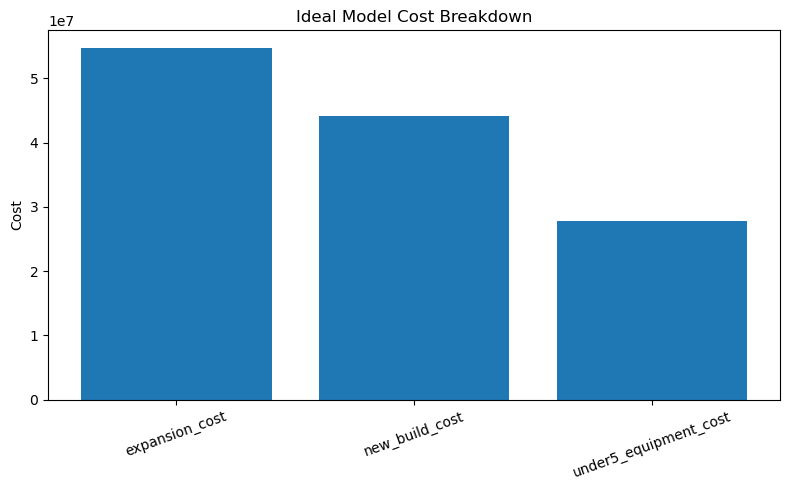

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_cost_breakdown_bar.png


In [14]:
#Figure 1: Cost breakdown bar chart
fig1 = objective_breakdown.loc[
    objective_breakdown["component"] != "total_objective"
].copy()

plt.figure(figsize=(8, 5))
plt.bar(fig1["component"], fig1["value"])
plt.title("Ideal Model Cost Breakdown")
plt.ylabel("Cost")
plt.xticks(rotation=20)
plt.tight_layout()

fig1_path = EXPORT_FIG_DIR / "ideal_cost_breakdown_bar.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

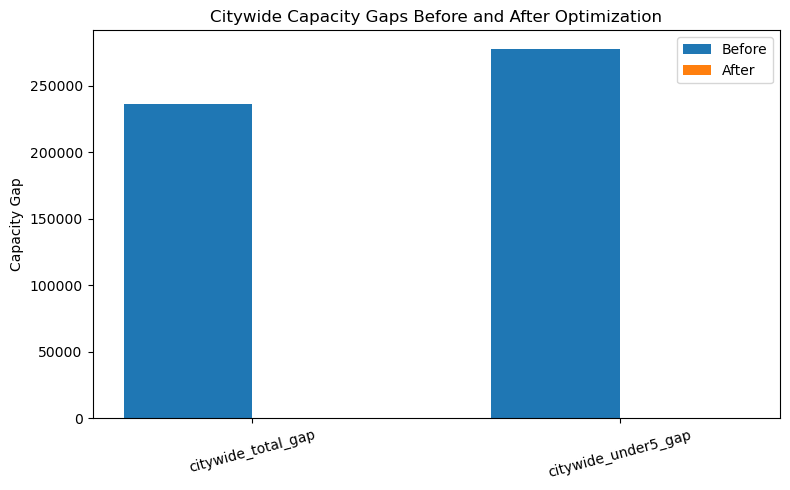

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_before_after_gap_bar.png


In [15]:
#Figure 2: Before vs after gaps
gap_compare = before_after_summary.loc[
    before_after_summary["metric"].isin(["citywide_total_gap", "citywide_under5_gap"])
].copy()

plt.figure(figsize=(8, 5))
x = np.arange(len(gap_compare))
width = 0.35

plt.bar(x - width/2, gap_compare["before"], width, label="Before")
plt.bar(x + width/2, gap_compare["after"], width, label="After")

plt.xticks(x, gap_compare["metric"], rotation=15)
plt.ylabel("Capacity Gap")
plt.title("Citywide Capacity Gaps Before and After Optimization")
plt.legend()
plt.tight_layout()

fig2_path = EXPORT_FIG_DIR / "ideal_before_after_gap_bar.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

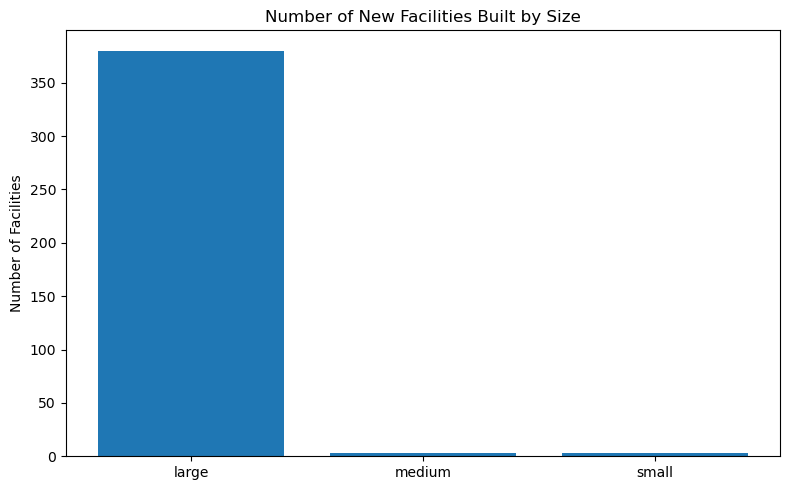

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_new_facilities_by_size.png


In [16]:
#Figure 3: New facilities by size
plt.figure(figsize=(8, 5))

if len(new_build_by_size) > 0:
    plt.bar(new_build_by_size["size"], new_build_by_size["num_new_facilities"])
    plt.title("Number of New Facilities Built by Size")
    plt.ylabel("Number of Facilities")
else:
    plt.text(0.5, 0.5, "No new facilities built", ha="center", va="center")
    plt.title("Number of New Facilities Built by Size")
    plt.axis("off")

plt.tight_layout()

fig3_path = EXPORT_FIG_DIR / "ideal_new_facilities_by_size.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig3_path)

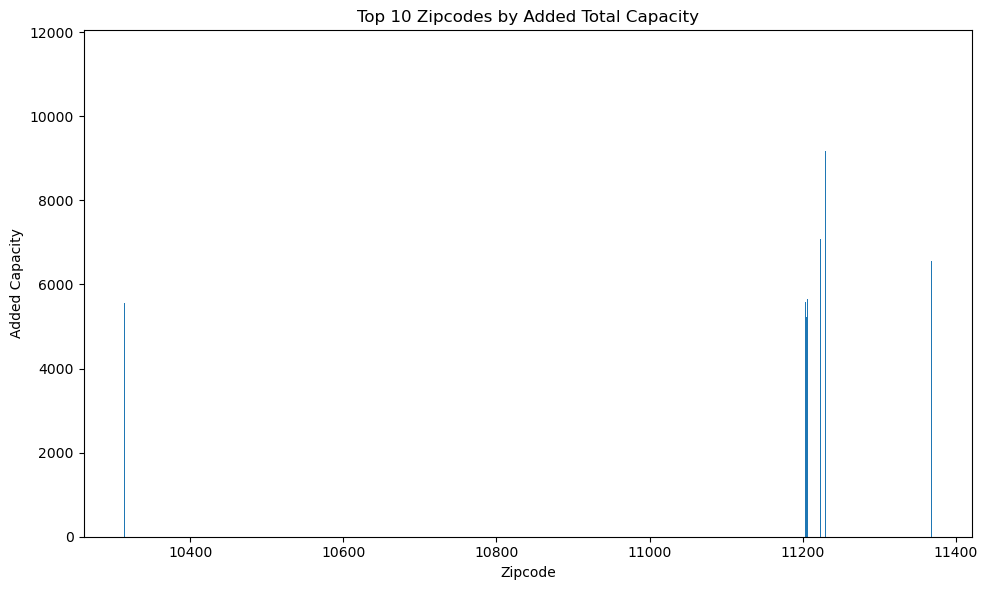

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_top10_zipcodes_added_capacity.png


In [17]:
#Figure 4: Top 10 zipcodes by added capacity
plot_top_zip = top_zipcodes_added.head(10).copy()

plt.figure(figsize=(10, 6))
plt.bar(plot_top_zip["zipcode"], plot_top_zip["added_total_capacity"])
plt.title("Top 10 Zipcodes by Added Total Capacity")
plt.ylabel("Added Capacity")
plt.xlabel("Zipcode")
plt.tight_layout()

fig4_path = EXPORT_FIG_DIR / "ideal_top10_zipcodes_added_capacity.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig4_path)

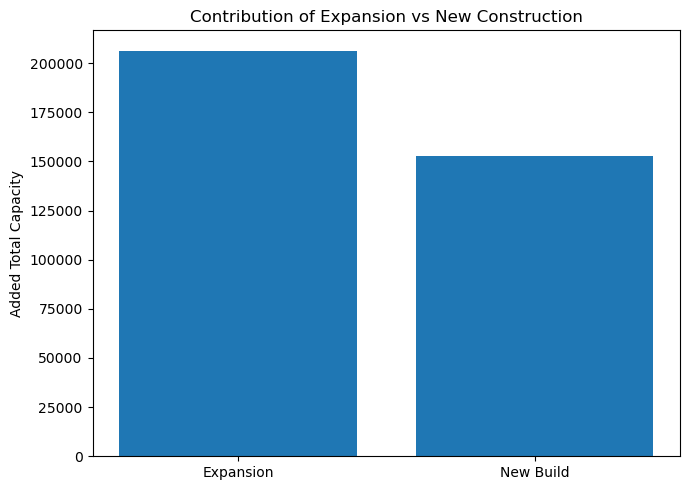

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_expansion_vs_newbuild_slots.png


In [18]:
#Figure 5: Expansion vs new-build contribution
contribution_values = pd.DataFrame({
    "source": ["Expansion", "New Build"],
    "slots": [
        zipcode_solution["added_total_expansion"].sum(),
        zipcode_solution["added_total_newbuild"].sum()
    ]
})

plt.figure(figsize=(7, 5))
plt.bar(contribution_values["source"], contribution_values["slots"])
plt.title("Contribution of Expansion vs New Construction")
plt.ylabel("Added Total Capacity")
plt.tight_layout()

fig5_path = EXPORT_FIG_DIR / "ideal_expansion_vs_newbuild_slots.png"
plt.savefig(fig5_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig5_path)

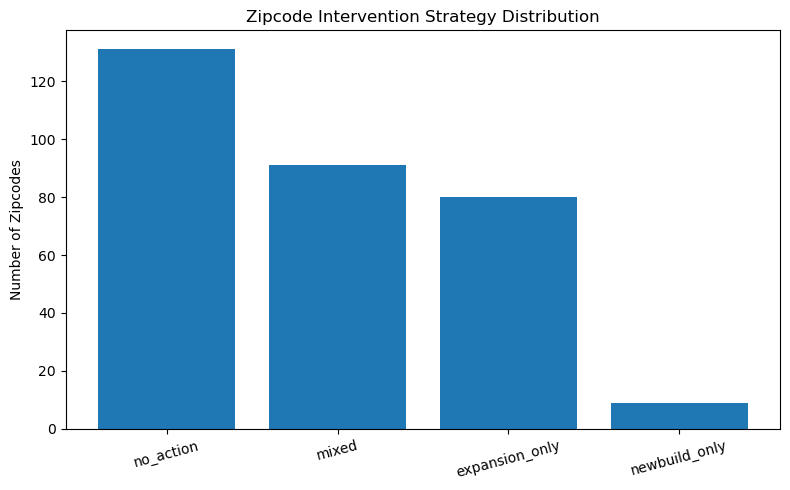

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_strategy_distribution.png


In [19]:
#Figure 6: Zipcode strategy distribution
plt.figure(figsize=(8, 5))
plt.bar(strategy_summary["strategy_type"], strategy_summary["count"])
plt.title("Zipcode Intervention Strategy Distribution")
plt.ylabel("Number of Zipcodes")
plt.xticks(rotation=15)
plt.tight_layout()

fig6_path = EXPORT_FIG_DIR / "ideal_strategy_distribution.png"
plt.savefig(fig6_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig6_path)

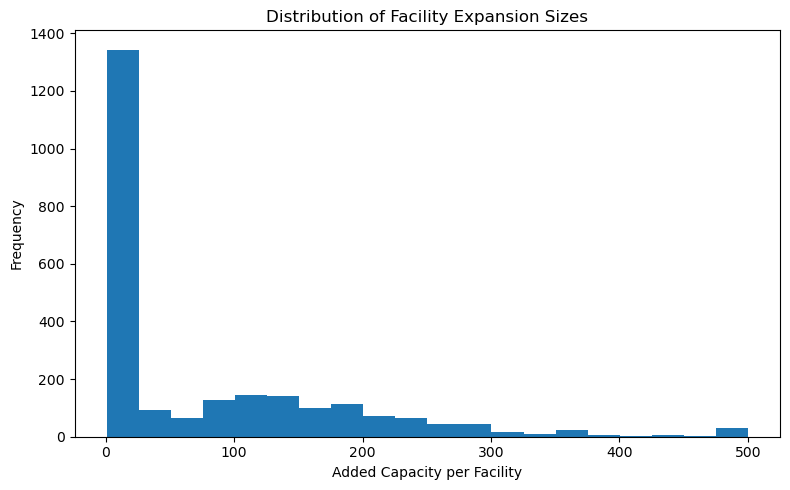

Saved: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/figures/ideal_facility_expansion_histogram.png


In [20]:
#Figure 7: Histogram of facility expansion sizes
facility_exp_nonzero = facility_solution.loc[facility_solution["x_added"] > 0, "x_added"]

plt.figure(figsize=(8, 5))
if len(facility_exp_nonzero) > 0:
    plt.hist(facility_exp_nonzero, bins=20)
    plt.title("Distribution of Facility Expansion Sizes")
    plt.xlabel("Added Capacity per Facility")
    plt.ylabel("Frequency")
else:
    plt.text(0.5, 0.5, "No facility expansions", ha="center", va="center")
    plt.title("Distribution of Facility Expansion Sizes")
    plt.axis("off")

plt.tight_layout()

fig7_path = EXPORT_FIG_DIR / "ideal_facility_expansion_histogram.png"
plt.savefig(fig7_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig7_path)

## Report-ready exports

The final cells package the benchmark tables used most directly in the written report.


In [21]:
#Report-ready table: main results table
main_results_table = pd.DataFrame([
    {
        "category": "Objective",
        "metric": "Minimum total funding",
        "value": objective_value
    },
    {
        "category": "Capacity added",
        "metric": "Added slots through expansion",
        "value": total_added_expansion
    },
    {
        "category": "Capacity added",
        "metric": "Added slots through new facilities",
        "value": total_added_newbuild
    },
    {
        "category": "Capacity added",
        "metric": "Added under-5 slots through expansion",
        "value": total_added_under5_expansion
    },
    {
        "category": "Capacity added",
        "metric": "Added under-5 slots through new facilities",
        "value": total_added_under5_newbuild
    },
    {
        "category": "Construction",
        "metric": "Total new facilities built",
        "value": total_new_facilities
    },
    {
        "category": "Coverage",
        "metric": "Zipcodes meeting all requirements after optimization",
        "value": int(zipcode_solution["all_requirements_met_after"].sum())
    },
    {
        "category": "Coverage",
        "metric": "Zipcodes failing at least one requirement after optimization",
        "value": int((zipcode_solution["all_requirements_met_after"] == 0).sum())
    }
])

display(main_results_table)

,category,metric,value
0,Objective,Minimum total funding,1.266689e+08
1,Capacity added,Added slots through expansion,2.063640e+05
2,Capacity added,Added slots through new facilities,1.529000e+05
3,Capacity added,Added under-5 slots through expansion,2.029380e+05
4,Capacity added,Added under-5 slots through new facilities,7.478300e+04
5,Construction,Total new facilities built,3.860000e+02
6,Coverage,Zipcodes meeting all requirements after optimi...,3.110000e+02
7,Coverage,Zipcodes failing at least one requirement afte...,0.000000e+00


In [22]:
#size-specific new build table
report_newbuild_table = new_build_by_size.copy()

if len(report_newbuild_table) > 0:
    report_newbuild_table["total_newbuild_related_cost"] = (
        report_newbuild_table["fixed_build_cost_total"] +
        report_newbuild_table["under5_equipment_cost_newbuild"]
    )

display(report_newbuild_table)

,size,num_new_facilities,total_new_under5_assigned,fixed_build_cost_total,under5_equipment_cost_newbuild,total_newbuild_related_cost
0,large,380.0,74393.0,43700000.0,7439300.0,51139300.0
1,medium,3.0,290.0,285000.0,29000.0,314000.0
2,small,3.0,100.0,195000.0,10000.0,205000.0


In [23]:
#top 10 intervention zipcodes
report_top_zipcodes_table = zipcode_solution.copy()

report_top_zipcodes_table["added_total_capacity"] = (
    report_top_zipcodes_table["added_total_expansion"] +
    report_top_zipcodes_table["added_total_newbuild"]
)

report_top_zipcodes_table["added_under5_capacity"] = (
    report_top_zipcodes_table["added_under5_expansion"] +
    report_top_zipcodes_table["added_under5_newbuild"]
)

report_top_zipcodes_table = report_top_zipcodes_table.sort_values(
    "added_total_capacity", ascending=False
)[[
    "zipcode",
    "high_demand",
    "existing_total",
    "req_total",
    "final_total_capacity",
    "existing_under5",
    "req_under5",
    "final_under5_capacity",
    "added_total_capacity",
    "added_under5_capacity",
    "num_new_facilities_total"
]].head(10).reset_index(drop=True)

display(report_top_zipcodes_table)

,zipcode,high_demand,existing_total,req_total,final_total_capacity,existing_under5,req_under5,final_under5_capacity,added_total_capacity,added_under5_capacity,num_new_facilities_total
0,11219,1,2595.0,13374,14067.0,1012.0,8084,8084.0,11472.0,7072.0,22.0
1,11230,0,824.0,5803,9991.0,312.0,5279,5279.0,9167.0,4967.0,21.0
2,11223,1,1448.0,7741,8532.0,144.0,4428,4428.0,7084.0,4284.0,14.0
3,11368,1,3057.0,9621,9621.0,502.0,5263,5263.0,6564.0,4761.0,9.0
4,11220,1,2251.0,8344,8344.0,396.0,3855,3855.0,6093.0,3459.0,11.0
5,11249,0,315.0,3204,6202.0,96.0,3183,3183.0,5887.0,3087.0,14.0
6,11206,1,3233.0,8618,8877.0,358.0,4802,4802.0,5644.0,4444.0,6.0
7,11204,1,3192.0,8683,8766.0,432.0,4806,4806.0,5574.0,4374.0,6.0
8,10314,0,1654.0,4624,7211.0,156.0,3513,3513.0,5557.0,3357.0,11.0
9,11205,0,918.0,3711,6150.0,136.0,3168,3168.0,5232.0,3032.0,11.0


In [24]:
#top expanded facilities
report_top_facilities_table = facility_solution.loc[
    facility_solution["x_added"] > 0,
    [
        "facility_id", "facility_name", "zipcode", "program_type",
        "n_f", "x_added", "u_under5_added", "delta_triggered",
        "expansion_cost", "under5_equipment_cost_expansion"
    ]
].sort_values("x_added", ascending=False).head(10).reset_index(drop=True)

display(report_top_facilities_table)

,facility_id,facility_name,zipcode,program_type,n_f,x_added,u_under5_added,delta_triggered,expansion_cost,under5_equipment_cost_expansion
0,866851,"Imogen Roche Foundation, Inc.",10016,SACC,480.0,500.0,500.0,1,120833.333333,50000.0
1,901628,Yeshivath Kehilath Yakov,11218,SACC,491.0,500.0,500.0,1,120366.598778,50000.0
2,628268,YMCA @ P.S. 48Q,11433,SACC,426.0,500.0,500.0,1,123474.178404,50000.0
3,476936,Maspeth Town Hall After School at PS49/IS49,11379,SACC,487.0,500.0,500.0,1,120533.880903,50000.0
4,338319,"MASPETH TOWN HALL, INC.",11377,SACC,480.0,500.0,500.0,1,120833.333333,50000.0
5,74148,MASPETH TOWN HALL PS 229,11377,SACC,535.0,500.0,500.0,0,125000.000000,50000.0
6,922382,"Kweller, Frances",11374,SACC,516.0,500.0,500.0,0,125000.000000,50000.0
7,899373,South Asian Youth Action (SAYA),11373,SACC,438.0,500.0,500.0,1,122831.050228,50000.0
8,121475,LATCH AFTERSCHOOL PROGRAM AT P.S. 89Q,11373,SACC,720.0,500.0,500.0,0,125000.000000,50000.0
9,74233,SAMUEL FIELD Y/BAY TERRACE BEACON JHS 216,11365,SACC,440.0,500.0,500.0,1,122727.272727,50000.0


In [25]:
before_after_summary.to_csv(EXPORT_TABLE_DIR / "ideal_before_after_summary.csv", index=False)
overall_plan_summary.to_csv(EXPORT_TABLE_DIR / "ideal_overall_plan_summary.csv", index=False)
cost_breakdown_table.to_csv(EXPORT_TABLE_DIR / "ideal_cost_breakdown_table.csv", index=False)
new_build_by_size.to_csv(EXPORT_TABLE_DIR / "ideal_new_build_by_size.csv", index=False)
top_zipcodes_added.to_csv(EXPORT_TABLE_DIR / "ideal_top_zipcodes_added_capacity.csv", index=False)
top_facilities_expansion.to_csv(EXPORT_TABLE_DIR / "ideal_top_facilities_expansion.csv", index=False)
strategy_summary.to_csv(EXPORT_TABLE_DIR / "ideal_strategy_summary.csv", index=False)

main_results_table.to_csv(EXPORT_TABLE_DIR / "ideal_main_results_table.csv", index=False)
report_newbuild_table.to_csv(EXPORT_TABLE_DIR / "ideal_report_newbuild_table.csv", index=False)
report_top_zipcodes_table.to_csv(EXPORT_TABLE_DIR / "ideal_report_top_zipcodes_table.csv", index=False)
report_top_facilities_table.to_csv(EXPORT_TABLE_DIR / "ideal_report_top_facilities_table.csv", index=False)

print("Report tables exported to:", EXPORT_TABLE_DIR)

Report tables exported to: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/data/exports/tables_for_report
